In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import cv2
from tensorflow.keras.optimizers import Adamax

In [ ]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1


In [ ]:
train_df="/root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1/Training"
test_df="/root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1/Testing"

In [ ]:
img_height, img_width = 128, 128  # Reduced image size
batch_size = 16

In [ ]:
filepaths = []
labels = []

folds = os.listdir(train_df)

for fold in folds:
    foldpath = os.path.join(train_df, fold)

    files = os.listdir(foldpath)
    for f in files:
        fpath = os.path.join(foldpath, f)

        filepaths.append(fpath)
        labels.append(fold)

train_df = pd.DataFrame(data={'filepaths':filepaths, 'labels':labels})
train_df

,filepaths,labels
0,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
1,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
2,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
3,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
4,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
...,...,...
5707,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
5708,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
5709,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
5710,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary


In [ ]:
filepaths = []
labels = []

folds = os.listdir(test_df)

for fold in folds:
    foldpath = os.path.join(test_df, fold)

    files = os.listdir(foldpath)
    for f in files:
        fpath = os.path.join(foldpath, f)

        filepaths.append(fpath)
        labels.append(fold)

test_df = pd.DataFrame(data={'filepaths':filepaths, 'labels':labels})
test_df

,filepaths,labels
0,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
1,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
2,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
3,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
4,/root/.cache/kagglehub/datasets/masoudnickparv...,meningioma
...,...,...
1306,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
1307,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
1308,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary
1309,/root/.cache/kagglehub/datasets/masoudnickparv...,pituitary


In [ ]:
valid_df , test_df = train_test_split(test_df,test_size = 0.5,
                                      random_state=42)

In [ ]:
gen = ImageDataGenerator()
batch_size = 8
train_gen = gen.flow_from_dataframe(train_df , x_col = 'filepaths' ,
                                    y_col='labels',
                                    target_size=(128, 128),
                                    color_mode = 'rgb',
                                    class_mode = 'categorical',
                                    batch_size = 32)


test_gen = gen.flow_from_dataframe(test_df , x_col = 'filepaths' ,
                                    y_col='labels',
                                    target_size=(128, 128),
                                    color_mode = 'rgb',
                                    class_mode = 'categorical',
                                    batch_size = 32)


valid_gen = gen.flow_from_dataframe(valid_df , x_col = 'filepaths' ,
                                    y_col='labels',
                                    target_size=(128, 128),
                                    color_mode = 'rgb',
                                    class_mode = 'categorical',
                                    batch_size = 32)

Found 5712 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.


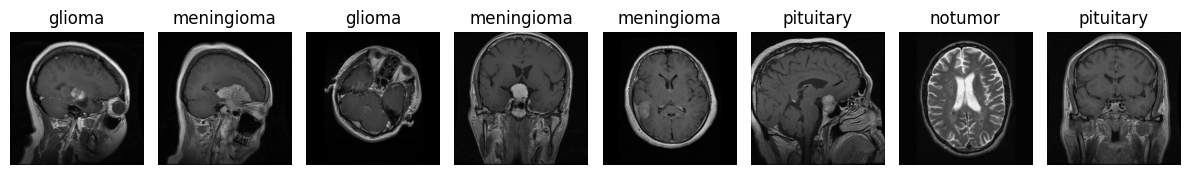

In [ ]:
 #Display some sample images from the DataFrame
def display_sample_images(dataframe, n=8):
    plt.figure(figsize=(12, 12))

    sample_df = dataframe.sample(n=n).reset_index(drop=True)

    for i in range(n):
        filepath = sample_df.loc[i, 'filepaths']
        label = sample_df.loc[i, 'labels']

        image = cv2.imread(filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct color display

        plt.subplot(1, n, i+1)
        plt.imshow(image)
        plt.title(label, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_sample_images(train_df, n=8)

In [ ]:
model = Sequential([
    Conv2D(1024, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3), padding='same'), # Changed input_shape to match generator output and added padding
    MaxPooling2D((2, 2)),
    Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'), # Added padding
    MaxPooling2D((2, 2)),
    Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'), # Added padding
    MaxPooling2D((2, 2)),
    # Reduced the number of Conv2D and MaxPooling2D layers
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_gen, validation_data=valid_gen, epochs=25)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 215s 900ms/step - accuracy: 0.5962 - loss: 15.5819 - val_accuracy: 0.8046 - val_loss: 0.4786
Epoch 2/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 550ms/step - accuracy: 0.8791 - loss: 0.3310 - val_accuracy: 0.8702 - val_loss: 0.3128
Epoch 3/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 552ms/step - accuracy: 0.9269 - loss: 0.2066 - val_accuracy: 0.9115 - val_loss: 0.2375
Epoch 4/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 550ms/step - accuracy: 0.9548 - loss: 0.1372 - val_accuracy: 0.9176 - val_loss: 0.2284
Epoch 5/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 553ms/step - accuracy: 0.9649 - loss: 0.0988 - val_accuracy: 0.9435 - val_loss: 0.1760
Epoch 6/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 554ms/step - accuracy: 0.9779 - loss: 0.0684 - val_accuracy: 0.9328 - val_loss: 0.2178
Epoch 7/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 555ms/step - accuracy: 0.9850 - loss: 0.0527 - val_accuracy: 0.9481 - val_loss: 0.1493
Epoch 8/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 141s 551ms/step - accuracy: 0.9828 - loss: 0.0494 

In [ ]:
train_score = model.evaluate(train_gen)
valid_score = model.evaluate(valid_gen)
test_score = model.evaluate(test_gen)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])

179/179 ━━━━━━━━━━━━━━━━━━━━ 33s 184ms/step - accuracy: 0.9955 - loss: 0.0171
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.9527 - loss: 0.2871
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9532 - loss: 0.3263
Train Loss:  0.013840525411069393
Train Accuracy:  0.9956232309341431
--------------------
Validation Loss:  0.2511875629425049
Validation Accuracy:  0.9496183395385742
--------------------
Test Loss:  0.35695070028305054
Test Accuracy:  0.9588414430618286


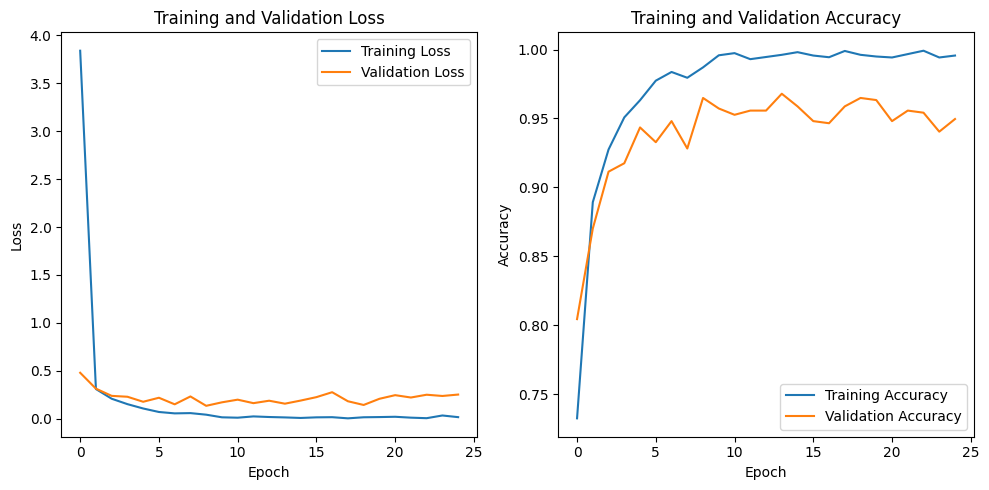

In [ ]:
# Plot Loss and Accuracy in Subplots
plt.figure(figsize=(10, 5))

# Loss Subplot
plt.subplot(1, 2, 1)  # Create first subplot occupying half the figure width
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Accuracy Subplot
plt.subplot(1, 2, 2)  # Create second subplot occupying the remaining half
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()  # Adjust spacing between subplots for better readability
plt.show()

In [ ]:
from google.colab import files
model.save('model.h5')

In [ ]:
files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>